### Understanding Dropout in Deep Learning: A Regularization Technique
Hello Guys, in this blog I am writing about my understanding on **Dropout**, a crucial regularization technique used in Deep Learning to combat overfitting. This blog will include the core intuition of dropout, its conceptual parallel with the bagging technique, theoretical references, and complete code implementation in a Jupyter Notebook format.

I am currently pursuing my Bachelor of Technology in **Smart Manufacturing** at the **PDPM Indian Institute of Information Technology, Design and Manufacturing, Jabalpur, MP**. I am an **AI/ML** enthusiast, and this write-up is part of my exploration into deep neural network optimization.

I am currently participating in a 8 week long **SUMMER OF ML** hosted by **BIT-BYTE TPC** under **Bsoc**

### 1. Introduction: The Overfitting Problem
When training deep neural networks with high capacity, the model often memorizes the training data—including noise and anomalies—rather than learning generalizable patterns. As a result, training error reduces, but test error increases.

To prevent this, we use Regularization. While techniques like **L1/L2 regularization** penalize large weights, Dropout takes a structural approach by randomly disabling neurons during training iterations.

### 2. Intuition & Analogy: The Bagging Connection
To understand dropout deeply, it helps to look at an analogy with traditional ensemble learning, specifically Bagging (Bootstrap Aggregating) like Random Forests:

Bagging Perspective: In bagging, we train multiple independent sub-models (decision trees) on different subsets of the data and average their predictions to reduce variance.

The Dropout Parallel: As explored in the foundational research on dropout, this technique can be viewed as training an exponentially large number of thinned sub-networks (sharing parameters) simultaneously. In every batch iteration, a different sub-network is sampled by randomly dropping out neurons. At test time, all neurons are active, combining the effect of these exponential networks (approximated efficiently via weight scaling).

Instead of co-adapting where neurons rely too heavily on specific neighbors, dropout forces every individual neuron to learn robust, independent features.

**Here is a simplified, step-by-step visual explanation of Dropout.**



### Step 1: The Standard Network (Overfitting)
To understand Dropout, we first look at a standard, fully connected neural network.

In the image below, every neuron (the glowing dots) in one layer is connected to every neuron in the next layer. When the network is this dense and complex, it has a high capacity to memorize the training data. While it seems powerful, this often leads to overfitting—it performs perfectly on training data but fails to generalize to new data.

<img src="2.png" width="600" alt="Standard Neural Network">

Step 2: Applying Dropout (Training Phase)
Now, we apply Dropout during the training process.

The image below illustrates what happens in a single training step. We randomly select a fraction of neurons (in this example, 50% of the hidden nodes) and temporarily "shut them off" or "drop them out." The faded grey neurons are inactive, and their connections are removed for this iteration.

How this helps:
Instead of relying on specific complex combinations of neurons (which causes overfitting), the network is forced to learn redundant features. Any single neuron must be capable of functioning without the presence of its specific neighboring neurons. This creates a much more robust model.

Note: This process only happens during training. For prediction (inference), all neurons are active.

<img src="1.png" width="600" alt="Neural Network with Dropout">

### 3. Jupyter Notebook Structure & Code Implementation
Below are the notebook cells mapping out data generation, standard deep learning regression without dropout, and the regularized model using the Dropout layer.

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Importing Dependencies

In this code cell, we import all the essential libraries required for building our neural network model, handling data manipulation, and plotting the performance curves. 

* **TensorFlow & Keras**: Used for constructing our sequential deep learning architecture, adding dense layers, dropout regularization, and configuring our optimizer.
* **NumPy & Matplotlib**: Used for managing numerical arrays and plotting our training progress and data distributions.
* **Scikit-Learn**: Used for data splitting (`train_test_split`) and computing evaluation metrics (`mean_squared_error`).

# Generate Data

In [11]:
X_train = np.linspace(-1, 1, 20)

In [12]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [13]:
X_test = np.linspace(-1, 1, 20)

In [14]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

### Generating Synthetic Data

In these code cells, we define our synthetic training and testing datasets for our regression demonstration:
* **`X_train` & `X_test`**: Created using `np.linspace(-1, 1, 20)` to generate 20 evenly spaced input data points between -1 and 1.
* **`y_train` & `y_test`**: Pre-defined target arrays containing 20 corresponding continuous output values for both our training and testing evaluations.

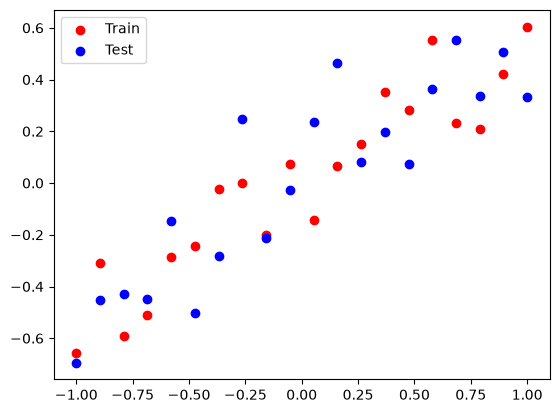

In [15]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

### Visualizing the Data Distribution

In this code cell, we use `matplotlib.pyplot` to create a scatter plot of our synthetic dataset. 
* **Red Markers (`c='red'`)**: Represent our training samples (`X_train`, `y_train`).
* **Blue Markers (`c='blue'`)**: Represent our testing samples (`X_test`, `y_test`).

Visualizing the data distribution helps us clearly inspect our input space before passing it into our deep neural network architectures.

# Regression Model

In [ ]:
model_1 = Sequential()
model_1.add(Dense(128, input_dim=1, activation="relu"))
model_1.add(Dense(128, activation="relu"))
model_1.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])
history = model_1.fit(X_train, y_train, epochs=500, 
                    validation_data = (X_test, y_test),
                    verbose=False)

### Building and Training the Baseline Model

In this code cell, we construct our first deep neural network (`model_1`) without any regularization:
* **Architecture**: A Sequential model featuring two dense hidden layers with 128 neurons each and `ReLU` activation, followed by a final linear output layer for regression.
* **Compilation**: Configured using the `Adam` optimizer with a learning rate of `0.01` and Mean Squared Error (`mse`) as both our loss function and evaluation metric.
* **Training**: Trained over `500` epochs using our training data while passing our test data as validation monitoring sets, with `verbose=False` to keep the output clean.

In [ ]:

_, train_mse = model_1.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.0037911939434707165, Test: 0.04586197808384895


In [18]:
y_pred_1 = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


### Evaluating and Predicting with the Baseline Model

In this code cell, we evaluate our trained baseline model and generate predictions:
* **Evaluation**: We compute the final Mean Squared Error (MSE) for both the training and test datasets using `.evaluate()` with `verbose=0` to suppress progress logs, then print out the respective scores.
* **Prediction**: We generate model predictions on our test input features (`X_test`) using `.predict()` to visualize how closely our unregularized network fits the data.

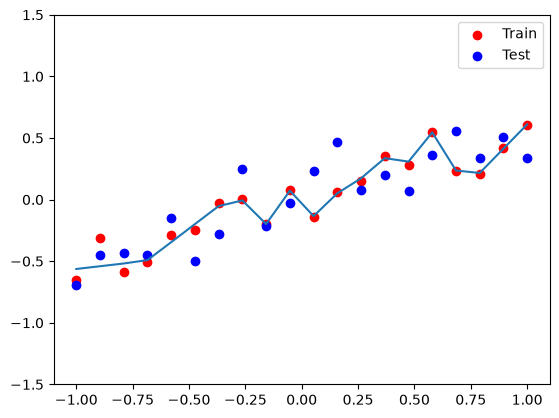

In [19]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

### Visualizing Baseline Model Predictions

In this code cell, we plot the regression fit of our baseline model against the actual data points:
* We create a figure displaying our training scatter points in **red** and test scatter points in **blue**.
* We overlay the model's predicted curve (`y_pred_1`) using `.plot()`.
* We set the y-axis limits using `plt.ylim((-1.5, 1.5))` and add a legend and grid view to clearly inspect how the unregularized model behaves across the dataset space.

# Dropout Model

***Doing same process as above, this time adding dropout after each layer and we're using dropout(0.2) means 20% of neurons will get switched off each epoch***

In [20]:
model_2 = Sequential()
model_2.add(Dense(128, input_dim=1, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.2))
model_2.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])

drop_out_history = model_2.fit(X_train, y_train, epochs=500, 
                               validation_data = (X_test, y_test),
                               verbose=False)

In [21]:
# evaluate the model
_, train_mse = model_2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.01210799254477024, Test: 0.039157185703516006


In [22]:
y_pred_2 = model_2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


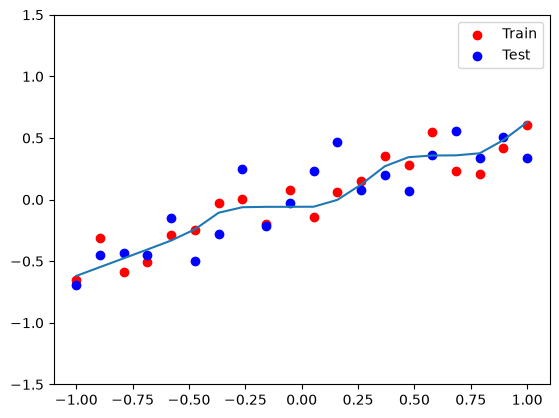

In [23]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

### After adding dropout
you can compare two curves before and after dropout you'll clearly spot the diffrence between generalising curve. 
the first curve trying to overfit the data but after adding dropout the overfitting effect reduced and second curve tried to focus more on generalising the data.

### Mathematical Deep Dive

For those who want to explore the rigorous mathematical foundations, optimization proofs, and weight scaling mechanics behind dropout, you can refer to the original foundational research paper:

* **Paper:** ["Dropout: A Simple Way to Prevent Neural Networks from Overfitting" by Nitish Srivastava, Geoffrey Hinton, Alex Krizhevsky, Ilya Sutskever, and Ruslan Salakhutdinov (2014)](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)

### Pro-Tip: Leveraging AI to Master the Research Paper

Because the foundational research paper on dropout contains dense mathematical formulations, proofs, and statistical analyses, you can use AI to help you digest it efficiently:

* **Section-by-Section Summaries:** Paste specific abstract, introduction, or model description paragraphs into an AI assistant to get plain-English breakdowns of core ideas like *co-adaptation* and *model combination*.
* **Clarifying Equations:** If you encounter complex notation regarding weight scaling or objective functions, ask your AI companion to walk through the equations step-by-step.
* **Key Takeaway Extraction:** Prompt the AI to summarize how dropout acts as an efficient approximation to training an exponential number of different neural network architectures simultaneously.

---

## 4. Conclusion & Final Thoughts

In this blog, we explored how **Dropout** serves as an indispensable tool in our deep learning toolbox. By randomly disabling a fraction of neurons during training, we prevent the network from developing brittle co-adaptations and force it to discover robust, redundant representations—mirroring the powerful variance-reduction benefits seen in ensemble methods like bagging.

We saw how unregularized deep networks can easily overfit even simple synthetic datasets, while introducing dropout helps stabilize performance and improves generalization. 

I hope this walkthrough helped clarify both the intuition and the practical application of dropout layers in TensorFlow and Keras! Feel free to fork this notebook, tweak the dropout rates, and experiment with your own datasets.

---

### **Acknowledgments & Credits**
A special thanks to **CampusX** and **Nitish Singh** for their exceptional educational content and deep learning tutorials, which provided fantastic reference materials and inspiration for the theoretical intuition behind this notebook.